In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
from sklearn.impute import  SimpleImputer 
from sklearn.compose import  ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import  train_test_split


In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
data=sns.load_dataset ('taxis')

In [4]:
data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
data.sample(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
5886,2019-03-22 14:19:23,2019-03-22 14:28:45,2,1.37,8.0,1.32,0.0,10.12,green,credit card,East Harlem South,East Harlem North,Manhattan,Manhattan
2697,2019-03-05 11:03:14,2019-03-05 11:33:35,1,3.87,20.0,4.66,0.0,27.96,yellow,credit card,Union Sq,Upper East Side North,Manhattan,Manhattan
5734,2019-03-04 06:42:59,2019-03-04 06:53:27,1,2.71,10.5,0.00,0.0,11.30,green,credit card,Prospect-Lefferts Gardens,Clinton Hill,Brooklyn,Brooklyn
2056,2019-03-23 19:23:50,2019-03-23 19:27:25,1,0.51,4.5,1.00,0.0,8.80,yellow,credit card,Clinton East,Clinton East,Manhattan,Manhattan
3502,2019-03-20 20:17:18,2019-03-20 20:23:32,1,0.94,6.0,1.47,0.0,11.27,yellow,credit card,Murray Hill,Union Sq,Manhattan,Manhattan


In [6]:
data.shape

(6433, 14)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [8]:
data.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [9]:
data.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [10]:
original_columns = data.columns
imput=SimpleImputer(fill_value=np.nan,strategy='most_frequent')

In [11]:
data.iloc[:,8:]=imput.fit_transform(data.iloc[:,8:])

data=np.array(data)


In [12]:
data=pd.DataFrame(data,columns=original_columns)

In [13]:
data.isna().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [14]:
data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.6,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.0,0.0,9.3,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.7,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.1,0.0,13.4,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


<Axes: >

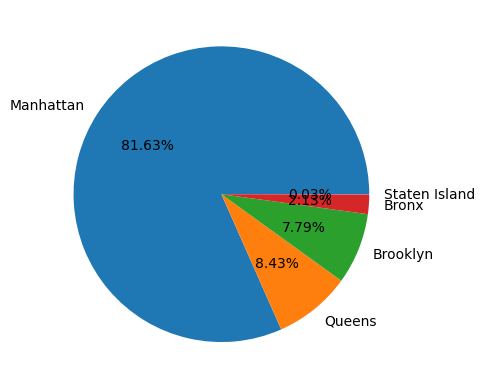

In [17]:
data['dropoff_borough'].value_counts().plot(kind='pie',autopct='%.2f%%')

<Axes: >

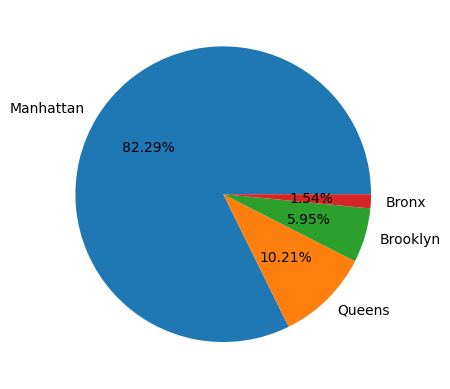

In [18]:
data['pickup_borough'].value_counts().plot(kind='pie',autopct='%.2f%%')

<Axes: >

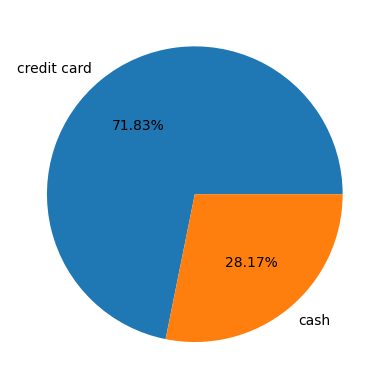

In [19]:
data['payment'].value_counts().plot(kind='pie',autopct='%.2f%%')

In [31]:
data1=data['pickup_zone'].values[:50]


data1

<ArrowStringArray>
[              'Lenox Hill West',         'Upper West Side South',
                 'Alphabet City',                     'Hudson Sq',
                  'Midtown East',     'Times Sq/Theatre District',
             'Battery Park City',                   'Murray Hill',
             'East Harlem South',           'Lincoln Square East',
             'LaGuardia Airport',         'Upper West Side South',
                   'Murray Hill',           'Lincoln Square West',
      'Financial District North',         'Upper West Side North',
                  'East Chelsea',                'Midtown Center',
                      'Gramercy',                  'East Chelsea',
  'Penn Station/Madison Sq West',  'Penn Station/Madison Sq West',
             'LaGuardia Airport', 'Sutton Place/Turtle Bay North',
               'Lenox Hill West',           'Lincoln Square East',
     'West Chelsea/Hudson Yards',                  'Clinton East',
                  'Clinton West',          

<Axes: >

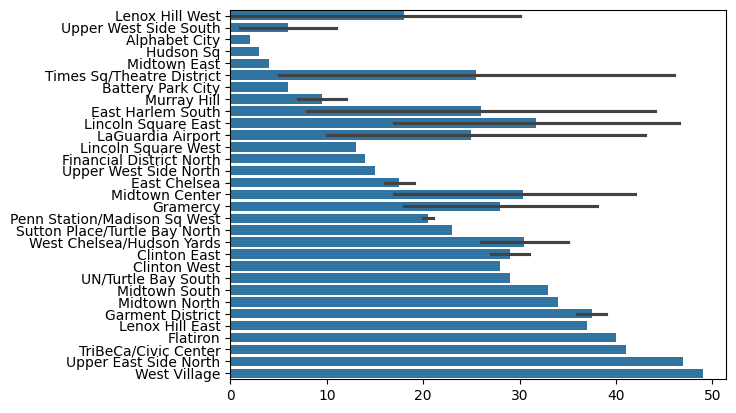

In [32]:
sns.barplot(data1)

<Axes: >

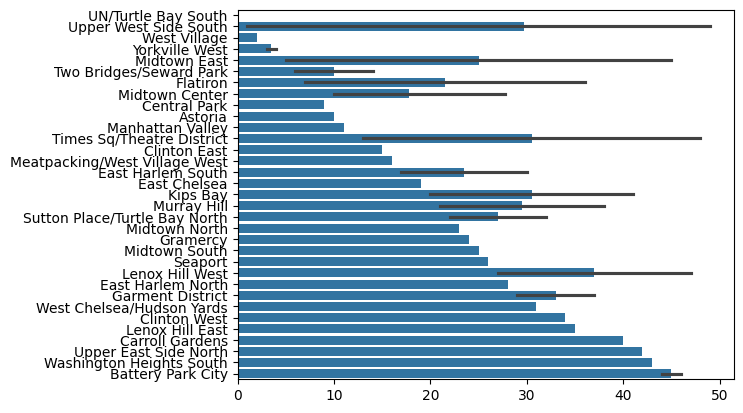

In [35]:
data2=data['dropoff_zone'].values[:50]

sns.barplot(data2 )

<Axes: ylabel='color'>

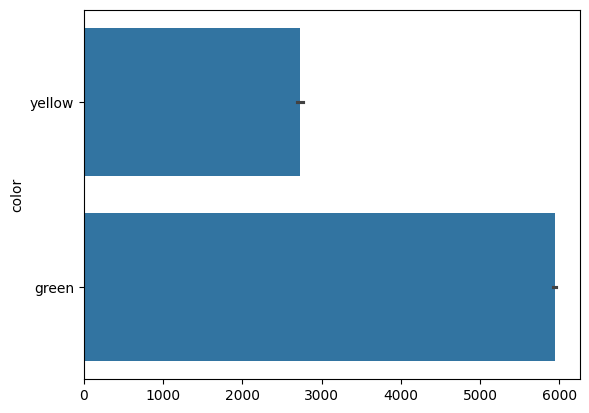

In [46]:
sns.barplot(data['color'])